In [1]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os

In [2]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
    "Battery" : "#8226A7",
}

# Colonnes production (positives)
prod_cols = [
    'H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
    'STEP_discharge','Battery_discharge','Solar'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

In [ ]:
timing_1 = "results/timing_logB939D933_ancien_xlsx_loading_HiGHS.csv"
timing_2 = "results/timing_log5BB0587E_chargement_enRAM_au_début.csv"
timing_3 = "results/timing_log_60193D33_ancienXlSX_laoding_sans_start_value.csv"
timing_4 = "results/timing_log_D8B55459_Gurobi_sans_start_value_chargement_ram.csv"
timing_5 = "results/timing_log45C8DE08_nouveaux_hyperparamètres_HiGHS_parallel.csv"
timing_6 = "results/timing_logFF793A_HighS_best_windows.csv"

timing_df = pd.read_csv(timing_1, sep=";")
timing_df_2 = pd.read_csv(timing_2, sep=";")
timing_df_3 = pd.read_csv(timing_3, sep=";")
timing_df_4 = pd.read_csv(timing_4, sep=";")
timing_df_5 = pd.read_csv(timing_5, sep=";")
timing_df_6 = pd.read_csv(timing_6, sep=";")

import matplotlib.pyplot as plt
import numpy as np

# Liste des DataFrames dans l'ordre de ta progression
dfs = [timing_df, timing_df_3, timing_df_2, timing_df_5, timing_df_4, timing_df_6]

# Labels qui expliquent l'incrément
cumulative_labels = [
    "Baseline (HiGHS)",
    "+ No Start Value",
    "+ RAM Loading",
    "+ Parallelism (OPTIMAL)",
    "Gurobi (meilleure configuration HiGHS)",
]

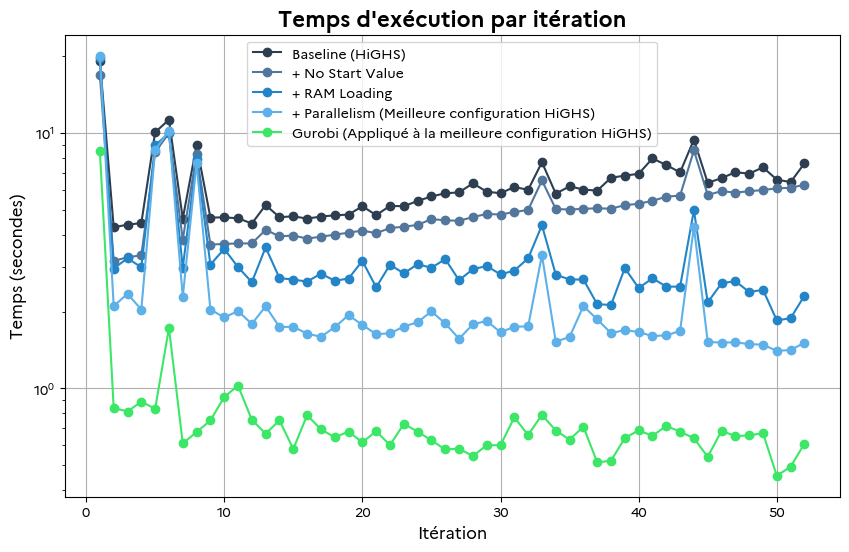

In [25]:
plt.figure(figsize=(10, 6))
color_palette = [
    "#2c3e50", # Baseline (Sombre/Lourd)
    "#53779c", # + No Start
    "#2385c7", # + RAM
    "#5db0e8", # + Parallel (Le plus optimisé HiGHS)
    "#3ce767", # Gurobi (Rouge pour marquer le changement de moteur)
    "#d29b2c"  # Windows (Gris pour l'aspect environnement différent)
]

for i, df in enumerate(dfs):
    if i < len(cumulative_labels):  # S'assurer de ne pas dépasser les labels disponibles
        plt.plot(df["iteration"], df["temps_secondes"], marker='o', label=cumulative_labels[i], color=color_palette[i])
    
plt.grid()
plt.xlabel("Itération")
plt.ylabel("Temps (secondes)")
plt.title("Temps d'exécution par itération")
plt.yscale("log")  # Utilisation d'une échelle logarithmique pour mieux visualiser les différences
plt.legend()

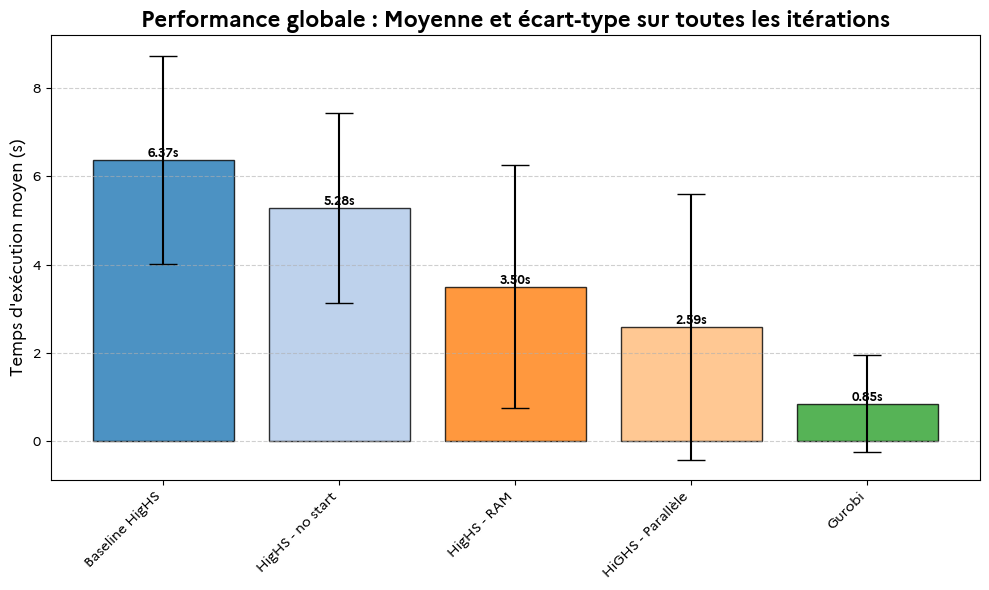

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Préparation des données
labels = [
    "Baseline HigHS", 
    "HigHS - no start", 
    "HigHS - RAM", 
    "HiGHS - Parallèle", 
    "Gurobi"
]
dfs = [timing_df, timing_df_3, timing_df_2, timing_df_5, timing_df_4]

# Calcul des métriques
means = [df["temps_secondes"].mean() for df in dfs]
stds = [df["temps_secondes"].std() for df in dfs]

# Tracé
plt.figure(figsize=(10, 6))
color_palette = plt.get_cmap("tab20").colors
x_pos = np.arange(len(labels))

bars = plt.bar(x_pos, means, yerr=stds, align='center', 
               alpha=0.8, color=color_palette[:len(labels)], 
               capsize=10, edgecolor='black')

# Personnalisation
plt.ylabel('Temps d\'exécution moyen (s)')
plt.xticks(x_pos, labels, rotation=45, ha="right")
plt.title('Performance globale : Moyenne et écart-type sur toutes les itérations')
plt.grid(axis='y', linestyle='--', alpha=0.6, which="both")

# Optionnel : Ajout de la valeur textuelle au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}s', 
             va='bottom', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()